In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import torch.optim as optim
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
scaler_X = MinMaxScaler()
dfs = pd.read_csv("../data/features.csv", index_col="Time_[s]")
targets = pd.read_csv("../data/targets.csv", index_col=False)
# df = dfs[dfs["Experiment_ID"]==2].drop(columns=["Experiment_ID"])
# target = targets[targets["Experiment_ID"]==2].iloc[:, 2:]
col = "Angle[degree]ORDistance[mm]"

scaler = MinMaxScaler(feature_range=(0, 1))
targets[col] = scaler.fit_transform(targets[[col]])
dfs

,Experiment_ID,MACHINE_BEND-DIE_LATERAL_Max_Torque_[%],MACHINE_BEND-DIE_ROTATING_Max_Torque_[%],MACHINE_BEND-DIE_VERTICAL_Max_Torque_[%],MACHINE_CLAMP-DIE_LATERAL_Max_Torque_[%],MACHINE_COLLET_AXIAL_Max_Torque_[%],MACHINE_COLLET_ROTATING_Max_Torque_[%],MACHINE_MANDREL_AXIAL_Max_Torque_[%],MACHINE_PRESSURE-DIE_LATERAL_Max_Torque_[%],MACHINE_PRESSURE-DIE_LEFT_AXIAL_Max_Torque_[%],BEND-DIE_LATERAL_Movement_[mm],BEND-DIE_ROTATING_Angle_[°],BEND-DIE_VERTICAL_Movement_[mm],CLAMP-DIE_LATERAL_Movement_[mm],COLLET_AXIAL_Movement_[mm],MANDREL_AXIAL_Movement_[mm],PRESSURE-DIE_AXIAL_Movement_[mm],PRESSURE-DIE_LATERAL_Movement_[mm]
Time_[s],,,,,,,,,,,,,,,,,,
0.00,2,0.135068,0.817045,0.293651,0.436154,0.397692,0.107143,0.985937,0.757580,0.59375,0.999967,1.000000,0.456468,0.570124,0.000005,0.900879,0.000373,0.999849
0.05,2,0.135068,0.817045,0.285714,0.436154,0.397822,0.107143,0.985937,0.750271,0.59375,0.999967,1.000000,0.456468,0.570124,0.000004,0.900879,0.000373,0.999842
0.10,2,0.135068,0.817045,0.293651,0.436154,0.398065,0.107143,0.984375,0.698300,0.59375,0.999967,1.000000,0.456468,0.570124,0.000004,0.900879,0.000373,0.999540
0.15,2,0.136307,0.817045,0.293651,0.436154,0.397887,0.107143,0.985937,0.585460,0.62500,0.999967,1.000000,0.456468,0.570124,0.000005,0.900879,0.000373,0.998401
0.20,2,0.135068,0.817045,0.285714,0.436154,0.397741,0.107143,0.984375,0.476972,0.65625,0.999967,1.000000,0.456468,0.570124,0.000002,0.900879,0.000373,0.997003
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
86.30,314,0.074349,0.875032,0.285714,0.419720,0.414831,0.785714,0.926562,0.793701,0.43750,0.000007,0.997979,0.456468,0.000004,0.984199,0.094463,0.000373,0.999849
86.35,314,0.074349,0.872084,0.293651,0.419720,0.415124,0.785714,0.928125,0.793552,0.43750,0.000007,0.998670,0.456468,0.000004,0.984199,0.094463,0.000373,0.999849
86.40,314,0.074349,0.874473,0.285714,0.419720,0.415188,0.785714,0.926562,0.793404,0.43750,0.000007,0.999223,0.456468,0.000004,0.984199,0.094463,0.000373,0.999849


In [12]:
import numpy as np

# Keep features with variance above a threshold
variance_threshold = 0.09
dfs = dfs.loc[:, dfs.var() > variance_threshold]

In [13]:
import numpy as np
import pandas as pd

# -----------------------------
# Example input: dfs and targets
# dfs: feature DataFrame with Experiment_ID and time-series features
# targets: target DataFrame with Experiment_ID and target features
# -----------------------------

# --- Step 1: Prepare Y (targets) ---
groups_y = []
max_len_y = targets.groupby("Experiment_ID").size().max()
num_target_features = targets.shape[1] - 1  # exclude Experiment_ID

for exp_id, group in targets.groupby("Experiment_ID"):
    values = group.drop(columns=["Experiment_ID"]).values  # (len_group, num_target_features)
    
    # Pad with NaN
    padded = np.full((max_len_y, num_target_features), np.nan)
    padded[:values.shape[0], :] = values
    groups_y.append(padded)

# Final y: (num_experiments, max_len, num_target_features)
y = np.array(groups_y, dtype=float)
Y = np.nan_to_num(y, nan=0.0)  # replace NaN with 0

# Optionally select specific target columns
Y = Y[:, :, 1:-1]  # adjust based on your targets

# --- Step 2: Prepare X (features) ---
groups = []
max_len = dfs.groupby("Experiment_ID").size().max()  # longest experiment
num_features = dfs.shape[1] - 1  # exclude Experiment_ID

for exp_id, group in dfs.groupby("Experiment_ID"):
    features = group.drop(columns=["Experiment_ID"]).values
    
    # Pad with NaN to match max_len
    padded = np.full((max_len, num_features), np.nan)  
    padded[:features.shape[0], :] = features
    groups.append(padded)

X = np.array(groups, dtype=float)
X = np.nan_to_num(X, nan=0.0)

print("Original X shape:", X.shape)
print("Original Y shape:", Y.shape)

# --- Step 3: Add only window features (no original columns) ---
def add_window_features_only(X, window_size=5):
    """
    Adds only rolling mean, std, diff, and EWMA features along the time axis (axis=1),
    excluding the original features.
    """
    num_experiments, max_len, num_features = X.shape
    new_features_list = []

    for i in range(num_experiments):
        df = pd.DataFrame(X[i])
        
        # Rolling features
        ärolling_mean = df.rolling(window=window_size, min_periods=1).mean()
        ewma         = df.ewm(span=window_size, adjust=False).mean()
        
        # Concatenate only the new features
        df_features = pd.concat([ewma], axis=1)
        new_features_list.append(df_features.values)

    return np.array(new_features_list, dtype=float)

# Apply window features
X_window = add_window_features_only(X, window_size=20)
print("X_window shape (new features only):", X_window.shape)
X = X_window.copy()


Original X shape: (100, 1743, 6)
Original Y shape: (100, 47, 4)
X_window shape (new features only): (100, 1743, 6)


In [14]:
num_samples, seq_len, num_features = X.shape
num_angles = Y.shape[1]
output_size = Y.shape[2]

# Prepare training data
X_rf = []
Y_rf = []

for sample_idx in range(num_samples):
    for angle_idx in range(num_angles):
        x_seq = X[sample_idx].flatten()  # Flatten sequence: seq_len*num_features
        degree = angle_idx / (num_angles - 1)  # Normalize angle index
        x_with_angle = np.append(x_seq, degree)  # Add angle as extra feature
        X_rf.append(x_with_angle)
        Y_rf.append(Y[sample_idx, angle_idx])  # shape (3,)

X_rf = np.array(X_rf)  # Shape: (num_samples*num_angles, seq_len*num_features + 1)
Y_rf = np.array(Y_rf)  # Shape: (num_samples*num_angles, 3)

In [19]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=None,
    max_features='sqrt',
    n_jobs=-1,
    oob_score=True,
    random_state=42,
    verbose=2
)

rf.fit(X_rf, Y_rf)

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.


building tree 1 of 100
building tree 2 of 100
building tree 3 of 100
building tree 4 of 100
building tree 5 of 100
building tree 6 of 100
building tree 7 of 100
building tree 8 of 100
building tree 9 of 100
building tree 10 of 100
building tree 11 of 100
building tree 12 of 100
building tree 13 of 100
building tree 14 of 100
building tree 15 of 100
building tree 16 of 100
building tree 17 of 100
building tree 18 of 100
building tree 19 of 100
building tree 20 of 100
building tree 21 of 100
building tree 22 of 100
building tree 23 of 100
building tree 24 of 100
building tree 25 of 100
building tree 26 of 100
building tree 27 of 100
building tree 28 of 100
building tree 29 of 100
building tree 30 of 100
building tree 31 of 100
building tree 32 of 100
building tree 33 of 100


[Parallel(n_jobs=-1)]: Done  25 tasks      | elapsed:    3.3s


building tree 34 of 100
building tree 35 of 100
building tree 36 of 100
building tree 37 of 100
building tree 38 of 100
building tree 39 of 100
building tree 40 of 100
building tree 41 of 100
building tree 42 of 100
building tree 43 of 100
building tree 44 of 100
building tree 45 of 100
building tree 46 of 100
building tree 47 of 100
building tree 48 of 100
building tree 49 of 100
building tree 50 of 100
building tree 51 of 100
building tree 52 of 100
building tree 53 of 100
building tree 54 of 100
building tree 55 of 100
building tree 56 of 100
building tree 57 of 100
building tree 58 of 100
building tree 59 of 100
building tree 60 of 100
building tree 61 of 100
building tree 62 of 100
building tree 63 of 100
building tree 64 of 100
building tree 65 of 100
building tree 66 of 100
building tree 67 of 100
building tree 68 of 100
building tree 69 of 100
building tree 70 of 100
building tree 71 of 100
building tree 72 of 100
building tree 73 of 100
building tree 74 of 100
building tree 75

[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:   12.2s finished


RandomForestRegressor(max_features='sqrt', n_jobs=-1, oob_score=True,
                      random_state=42, verbose=2)

[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  25 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    0.0s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  25 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    0.0s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  25 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    0.0s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  25 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    0.0s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  25 tasks      | elapsed:    0.0s
[Parallel(n_job

Comparing predictions for sample 50:
Angle  0: True=[0.         0.36111677 0.69118349 0.27649826], Pred=[0.01388277 0.35191984 0.66486399 0.30070867]
Angle  1: True=[0.02203614 0.34662522 0.65335099 0.3109318 ], Pred=[0.02379903 0.34539865 0.64783937 0.31620376]
Angle  2: True=[0.04407228 0.33194981 0.60898434 0.35198226], Pred=[0.04958131 0.32798162 0.59434754 0.36577729]
Angle  3: True=[0.06610842 0.31616954 0.55410445 0.40344548], Pred=[0.06368444 0.31812924 0.56017495 0.39781477]
Angle  4: True=[0.08814456 0.30040449 0.49438228 0.45985608], Pred=[0.09409431 0.29931345 0.48844426 0.46560245]
Angle  5: True=[0.1101807  0.29240916 0.45865753 0.4940144 ], Pred=[0.10797708 0.29417864 0.46604572 0.48698366]
Angle  6: True=[0.13221684 0.29055424 0.44873101 0.50361158], Pred=[0.13397973 0.29248346 0.45136133 0.5014838 ]
Angle  7: True=[0.15425297 0.29786392 0.45319747 0.50116356], Pred=[0.14587924 0.2959144  0.45318203 0.50061622]
Angle  8: True=[0.17628911 0.30573333 0.4622038  0.49424294

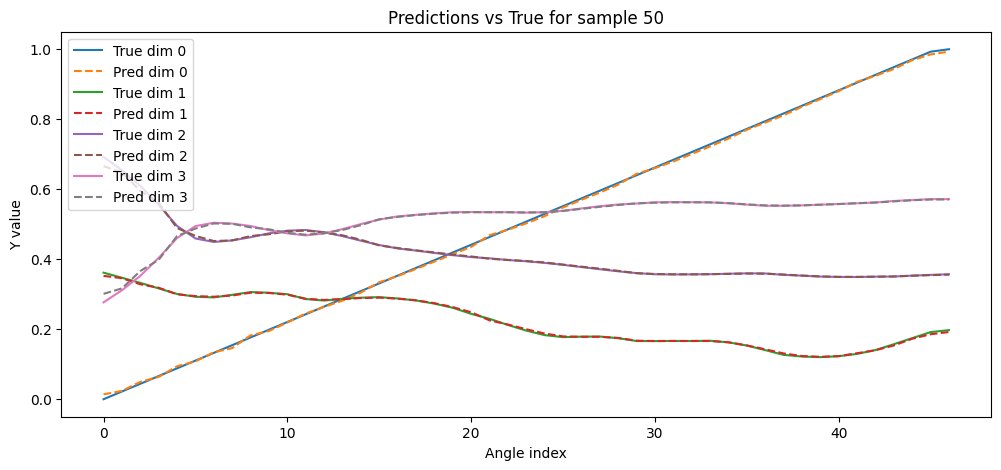

In [20]:
# ---------- Compare predictions for a sample ----------
sample_idx = 50
y_true = Y[sample_idx]  # Shape: (num_angles, 3)
y_pred = []

for angle_idx in range(num_angles):
    x_seq = X[sample_idx].flatten()
    degree = angle_idx / (num_angles - 1)
    x_with_angle = np.append(x_seq, degree)
    y_hat = rf.predict(x_with_angle.reshape(1, -1))
    y_pred.append(y_hat.flatten())

y_pred = np.array(y_pred)  # Shape: (num_angles, 3)

# ---------- Print comparison ----------
print(f"Comparing predictions for sample {sample_idx}:")
for angle_idx in range(num_angles):
    print(f"Angle {angle_idx:2d}: True={y_true[angle_idx]}, Pred={y_pred[angle_idx]}")

# ---------- Optional: plot comparison ----------
plt.figure(figsize=(12, 5))
for dim in range(output_size):
    plt.plot(range(num_angles), y_true[:, dim], label=f'True dim {dim}')
    plt.plot(range(num_angles), y_pred[:, dim], '--', label=f'Pred dim {dim}')
plt.xlabel('Angle index')
plt.ylabel('Y value')
plt.title(f'Predictions vs True for sample {sample_idx}')
plt.legend()
plt.show()

In [21]:
def plot_most_accurate_window_overlap(sample_idx, X, Y, rf,
                                      num_angles, num_features,
                                      patch_size, stride=10,
                                      angle_idx=0, seed=42):
    import matplotlib.pyplot as plt
    import numpy as np
    
    rng = np.random.default_rng(seed)  # reproducible randomness
    
    # ---------- Parameters ----------
    _, seq_len, _ = X.shape
    pad = patch_size // 2   # half-patch padding for indexing only
    
    # patch starting positions (with virtual padding, but not in model input)
    patch_starts = list(range(-pad, seq_len - patch_size + pad + 1, stride))
    num_patches = len(patch_starts)
    
    # ---------- Flatten input and append angle ----------
    x_input = X[sample_idx].flatten()
    degree = angle_idx / (num_angles - 1)
    x_with_angle = np.append(x_input, degree)
    y_true = np.array(Y[sample_idx, angle_idx])
    
    # ---------- Permutation-based error for each window ----------
    window_errors = []
    for w, start in enumerate(patch_starts):
        x_perm = x_with_angle.copy()
        
        # permute all *other* windows
        for wp, start_wp in enumerate(patch_starts):
            if wp != w:
                s = max(0, start_wp) * num_features
                e = min(seq_len, start_wp + patch_size) * num_features
                if e > s:
                    x_perm[s:e] = rng.permutation(x_perm[s:e])
        
        y_hat = np.array(rf.predict(x_perm.reshape(1, -1))[0])
        
        # scalar or vector case
        error = np.abs(y_true - y_hat) if y_true.ndim == 0 else np.linalg.norm(y_true - y_hat)
        window_errors.append(error)
    
    window_errors = np.array(window_errors)
    most_accurate_idx = np.argmin(window_errors)
    most_accurate_start = max(0, patch_starts[most_accurate_idx])
    most_accurate_end = min(seq_len, most_accurate_start + patch_size)
    
    # ---------- Plot features + highlight most accurate ----------
    plt.figure(figsize=(12, 6))
    for f in range(num_features):
        plt.plot(X[sample_idx, :, f], label=f'Feature {f}')
    
    plt.axvspan(most_accurate_start, most_accurate_end - 1,
                color='green', alpha=0.3, label='Most Accurate Window')
    
    # Overlay error curve mapped back to original sequence
    error_curve = np.zeros(seq_len)
    for i, start in enumerate(patch_starts):
        orig_start = max(0, start)
        orig_end = min(seq_len, start + patch_size)
        if orig_end > orig_start:
            error_curve[orig_start:orig_end] += window_errors[i]
    if np.max(error_curve) > 0:
        error_curve = error_curve / np.max(error_curve)
    
    ax2 = plt.gca().twinx()
    ax2.plot(range(seq_len), error_curve, color='black', linestyle='--',
             linewidth=2, label='Prediction Error per Patch (normalized)')
    ax2.set_ylabel("Relative Error")
    
    plt.xlabel("Timestep")
    plt.title(f"Sample {sample_idx}, Angle {angle_idx} - Overlapping Patches (stride={stride}, pad={pad})")
    plt.legend(loc='upper left')
    ax2.legend(loc='upper right')
    plt.show()
    
    # ---------- Predictions for all angles ----------
    preds = []
    for angle_idx_loop in range(num_angles):
        x_input = X[sample_idx].flatten()
        degree = angle_idx_loop / (num_angles - 1)
        x_with_angle = np.append(x_input, degree)
        y_hat = np.array(rf.predict(x_with_angle.reshape(1, -1))[0])
        preds.append(y_hat)
    preds = np.array(preds)
    
    # ---------- Plot true vs predicted ----------
    plt.figure(figsize=(12, 6))
    plt.plot(range(num_angles), Y[sample_idx], label='True', marker='o')
    plt.plot(range(num_angles), preds, label='Predicted', marker='x')
    plt.xlabel("Angle index")
    plt.ylabel("Target value(s)")
    plt.title(f"Predictions for Sample {sample_idx} across all angles")
    plt.legend()
    plt.grid(True)
    plt.show()


[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  25 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    0.0s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  25 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    0.0s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  25 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    0.0s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  25 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    0.0s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  25 tasks      | elapsed:    0.0s
[Parallel(n_job

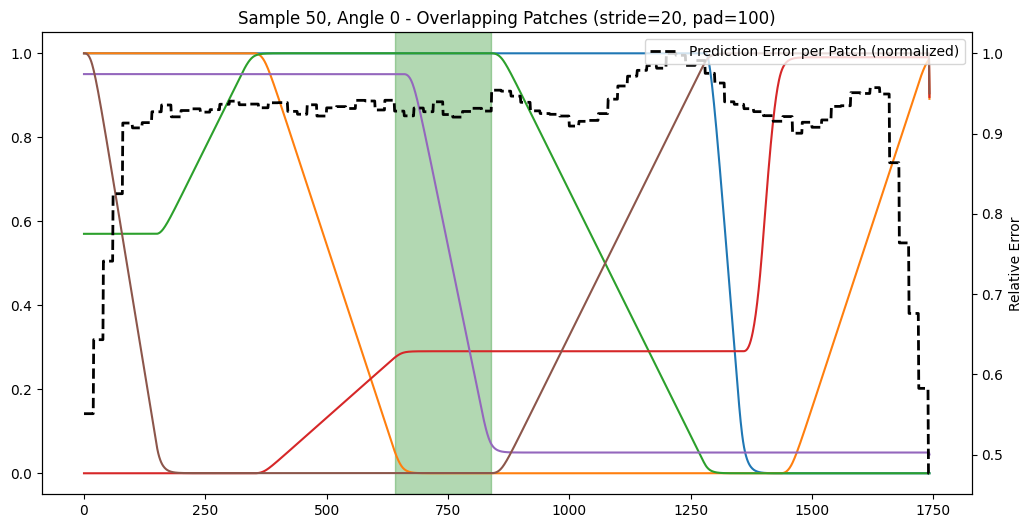

[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  25 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    0.0s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  25 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    0.0s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  25 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    0.0s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  25 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    0.0s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  25 tasks      | elapsed:    0.0s
[Parallel(n_job

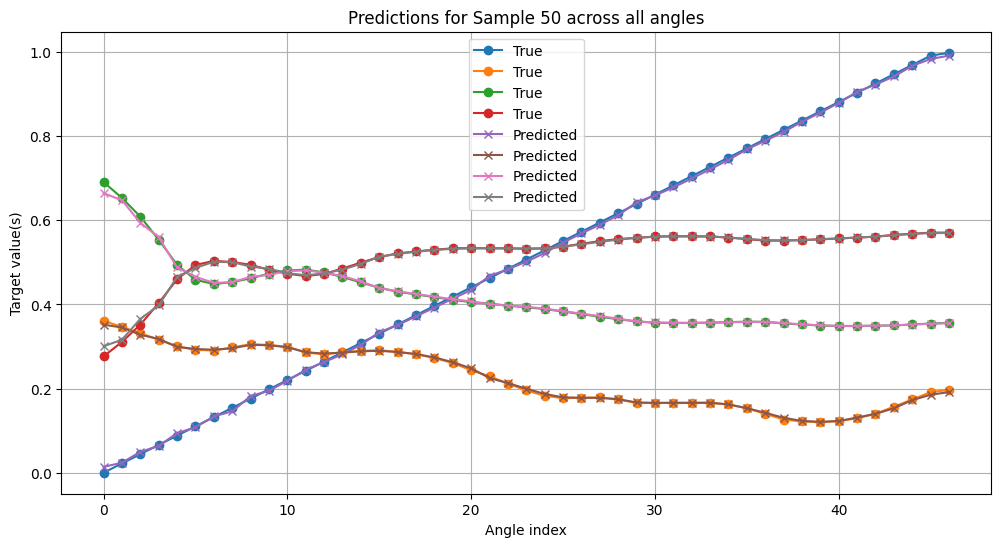

In [24]:
plot_most_accurate_window_overlap(sample_idx, X, Y, rf, num_angles, num_features, patch_size=200, stride=20, angle_idx=0, seed=42)
